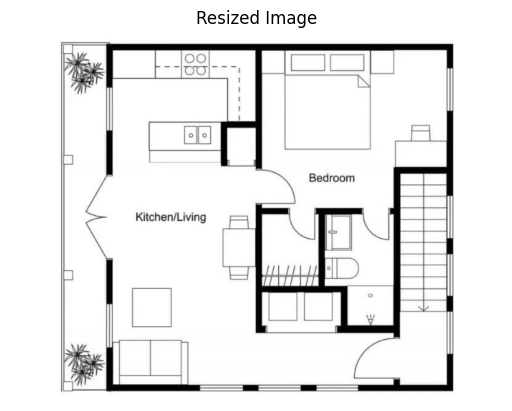

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\sketch3d\scripts\1-bedroom-house-plan.jpg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}")

# Resize the image
image = cv2.resize(image, (1024, 768))

# Show the image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")
plt.show()


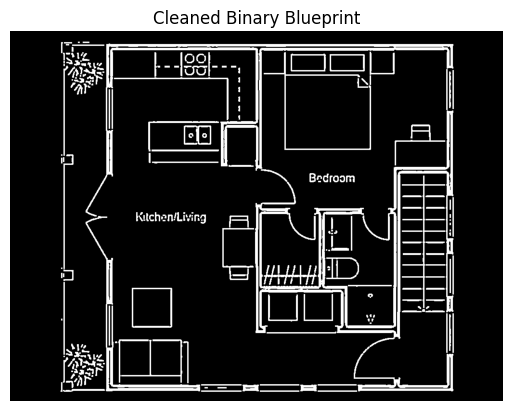

In [36]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 1: Denoise using Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 2: Adaptive Thresholding (handles lighting better)
binary = cv2.adaptiveThreshold(
    blurred, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

# Step 3: Morphological Opening (removes small noise)
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# Display cleaned binary image
plt.imshow(opened, cmap="gray")
plt.title("Cleaned Binary Blueprint")
plt.axis("off")
plt.show()


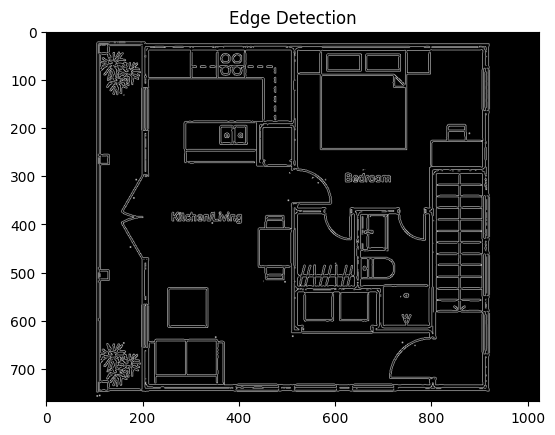

In [37]:
# Apply Canny Edge Detection
edges = cv2.Canny(binary, 50, 150)

# Display detected edges
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.show()


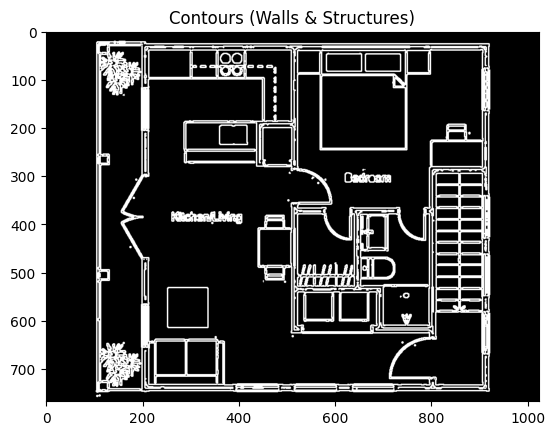

In [38]:
# Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank canvas
contour_image = np.zeros_like(gray)

# Draw contours on the blank image
cv2.drawContours(contour_image, contours, -1, (255, 255, 255), 2)

# Show detected contours
plt.imshow(contour_image, cmap='gray')
plt.title("Contours (Walls & Structures)")
plt.show()


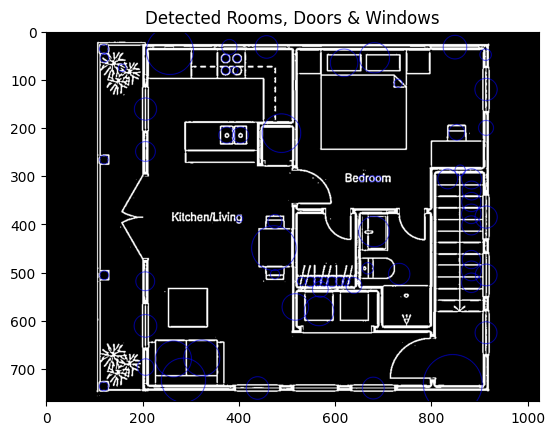

In [39]:
# Set up blob detector parameters
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 100  # Adjust as needed
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

# Create a detector with parameters
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs (rooms, doors, windows, furniture)
keypoints = detector.detect(binary)

# Draw detected blobs on the image
blob_image = cv2.drawKeypoints(binary, keypoints, np.array([]), (0, 0, 255), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Show detected blobs
plt.imshow(blob_image, cmap='gray')
plt.title("Detected Rooms, Doors & Windows")
plt.show()


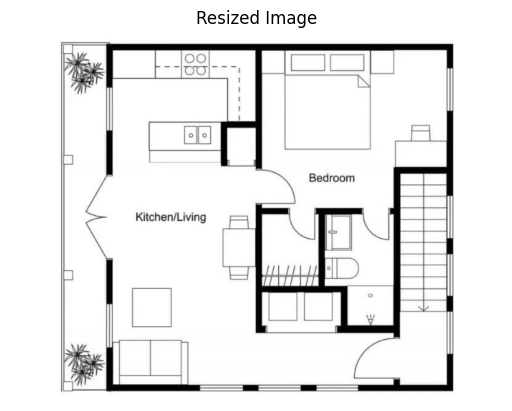

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image using correct name
image_path = r"C:\sketch3d\scripts\1-bedroom-house-plan.jpg"
image = cv2.imread(image_path)

# Check if image is loaded
if image is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}")

# Resize the image
image = cv2.resize(image, (1024, 768))

# Show the image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")
plt.show()


In [41]:
import json

# Convert contours to polylines
polylines = [contour[:, 0, :].tolist() for contour in contours]

# Save vector representation as JSON
vector_data = {"polylines": polylines}

with open(r"C:\sketch3d\scripts\1-bedroom-house-plan.jpg", "w") as f:
    json.dump(vector_data, f)

print("Vector representation saved as vector_data.json")


Vector representation saved as vector_data.json


In [42]:
import trimesh

# Define depth parameters
wall_height = 100  # Height of walls in 3D

# Convert contours to 3D points
vertices = []
faces = []

for polyline in polylines:
    for x, y in polyline:
        vertices.append([x, y, 0])  # Bottom
        vertices.append([x, y, wall_height])  # Top

# Create faces for walls
for i in range(0, len(vertices) - 2, 2):
    faces.append([i, i + 1, i + 2])
    faces.append([i + 1, i + 2, i + 3])

# Create and save 3D mesh
mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
mesh.export(r"C:\sketch3d\scripts\1-bedroom-house-plan.obj")  # Export as .obj


print("3D Model saved as 3d_model.obj")


3D Model saved as 3d_model.obj


In [1]:
import open3d as o3d

# Load 3D model
mesh = o3d.io.read_triangle_mesh(r"C:\sketch3d\scripts\1-bedroom-house-plan.obj")
mesh.compute_vertex_normals()

# Show 3D model
o3d.visualization.draw_geometries([mesh])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
